<a href="https://colab.research.google.com/github/abilashkannanv/AIML/blob/main/ComputerVisionSync1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Setup and Preparation**

First, let's ensure we have OpenCV installed and prepare our Colab environment.

In [ ]:
# Install OpenCV if not already available (usually pre-installed in Colab)
!pip install opencv-python-headless

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os # For file operations
from google.colab import files # For file uploads

print(f"OpenCV version: {cv2.__version__}")

OpenCV version: 4.13.0


### **2. Understanding Frame Differencing**

Frame Differencing is a very simple and intuitive motion detection technique. It works on the principle that if there's movement between two consecutive video frames, the pixels in the moving regions will have significantly different intensity values.

The basic idea is:
$D\_t = |I\_t - I\_{t-1}|$

Where:

  * $D\_t$ is the difference image at time $t$.
  * $I\_t$ is the current frame.
  * $I\_{t-1}$ is the previous frame.
  * The absolute difference is taken to ensure positive values.

Pixels with a high difference value indicate motion, while low differences suggest static regions.

-----

### **3. Motion Detection Implementation**

Now, let's implement the frame differencing algorithm in Python using OpenCV.

We will:

1.  Read the video frame by frame.
2.  Convert frames to grayscale to simplify calculations (motion is often about intensity changes, not color).
3.  Calculate the absolute difference between consecutive grayscale frames.
4.  Apply a threshold to this difference image to create a binary mask, highlighting areas of significant change.
5.  Perform morphological operations (like dilation) to close small gaps in the motion areas.
6.  Find contours in the binary mask to identify distinct motion regions.
7.  Draw bounding boxes around these motion regions on the original color frame.

<!-- end list -->

In [ ]:
# Function to perform motion detection
def detect_motion_frame_differencing(video_path, min_area=500):
    # Open the video file
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return

    # Read the first frame as the initial previous frame
    ret, frame1 = cap.read()
    if not ret:
        print("Error: Could not read the first frame.")
        return

    print(type(frame1))
    print(frame1.ndim)
    print(frame1.shape)
    # Convert the first frame to grayscale
    gray_frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    # Apply a blur to reduce noise, making the difference more stable
    gray_frame1 = cv2.GaussianBlur(gray_frame1, (21, 21), 0)

    # Prepare for displaying results in Colab (optional but good practice)
    # For live display in Colab, we'll collect frames and show them later
    # or show periodically. For simplicity, let's process and show a few results.

    output_frames = []
    frame_count = 0

    print("Processing video frames for motion detection...")

    while True:
        ret, frame2 = cap.read()
        if not ret:
            break # End of video

        # Convert current frame to grayscale
        gray_frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
        gray_frame2 = cv2.GaussianBlur(gray_frame2, (21, 21), 0)

        # Calculate the absolute difference between the current and previous frame
        frame_diff = cv2.absdiff(gray_frame1, gray_frame2)

        # Apply a threshold to the difference image
        # Pixels with intensity > threshold_value become 255 (white), others 0 (black)
        # THRESH_BINARY creates a binary image (0 or 255)
        # THRESH_OTSU automatically determines the optimal threshold value
        _, thresh = cv2.threshold(frame_diff, 25, 255, cv2.THRESH_BINARY) # threshold_value=25, max_value=255

        # Perform morphological operations to clean up the binary image
        # Dilation expands the white regions, helping to connect nearby motion pixels
        # Iterations define how many times the dilation is applied
        dilated = cv2.dilate(thresh, None, iterations=2)

        # Find contours in the dilated image
        # RETR_EXTERNAL retrieves only the extreme outer contours
        # CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments
        contours, _ = cv2.findContours(dilated.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw bounding boxes around detected motion regions
        current_frame_with_motion = frame2.copy() # Make a copy to draw on
        motion_detected = False

        for contour in contours:
            # Filter out small contours which might be noise
            if cv2.contourArea(contour) < min_area:
                continue

            (x, y, w, h) = cv2.boundingRect(contour)
            cv2.rectangle(current_frame_with_motion, (x, y), (x + w, y + h), (0, 255, 0), 2) # Green box
            motion_detected = True

        # Store frames for later display (e.g., every 30th frame or if motion detected)
        if motion_detected or frame_count % 30 == 0: # Save frames every second or when motion is detected
            output_frames.append(cv2.cvtColor(current_frame_with_motion, cv2.COLOR_BGR2RGB))
            # Also store the difference and thresholded images for visualization
            output_frames.append(cv2.cvtColor(frame_diff, cv2.COLOR_GRAY2RGB)) # Convert grayscale diff to RGB for plotting
            output_frames.append(cv2.cvtColor(dilated, cv2.COLOR_GRAY2RGB)) # Convert grayscale dilated to RGB for plotting


        # Update the previous frame for the next iteration
        gray_frame1 = gray_frame2
        frame_count += 1

    cap.release()
    print(f"Finished processing. Captured {len(output_frames)} visualization frames.")
    return output_frames

# --- Run the motion detection ---
# You can adjust `min_area` to filter out smaller noise detections.
# A smaller value detects smaller movements, a larger value ignores subtle changes.
processed_frames = detect_motion_frame_differencing('/content/Normal_Videos020_x264.mp4', min_area=1000)

<class 'numpy.ndarray'>
3
(240, 320, 3)
Processing video frames for motion detection...
Finished processing. Captured 114 visualization frames.


### **4. Visualize Results**

Since we cannot directly show live video output in Google Colab's standard cell, we'll display a selection of the processed frames using `matplotlib`. This will allow you to see the original frame with bounding boxes, the raw difference image, and the thresholded/dilated motion mask.


Displaying first 3 detected motion events or sampled frames:


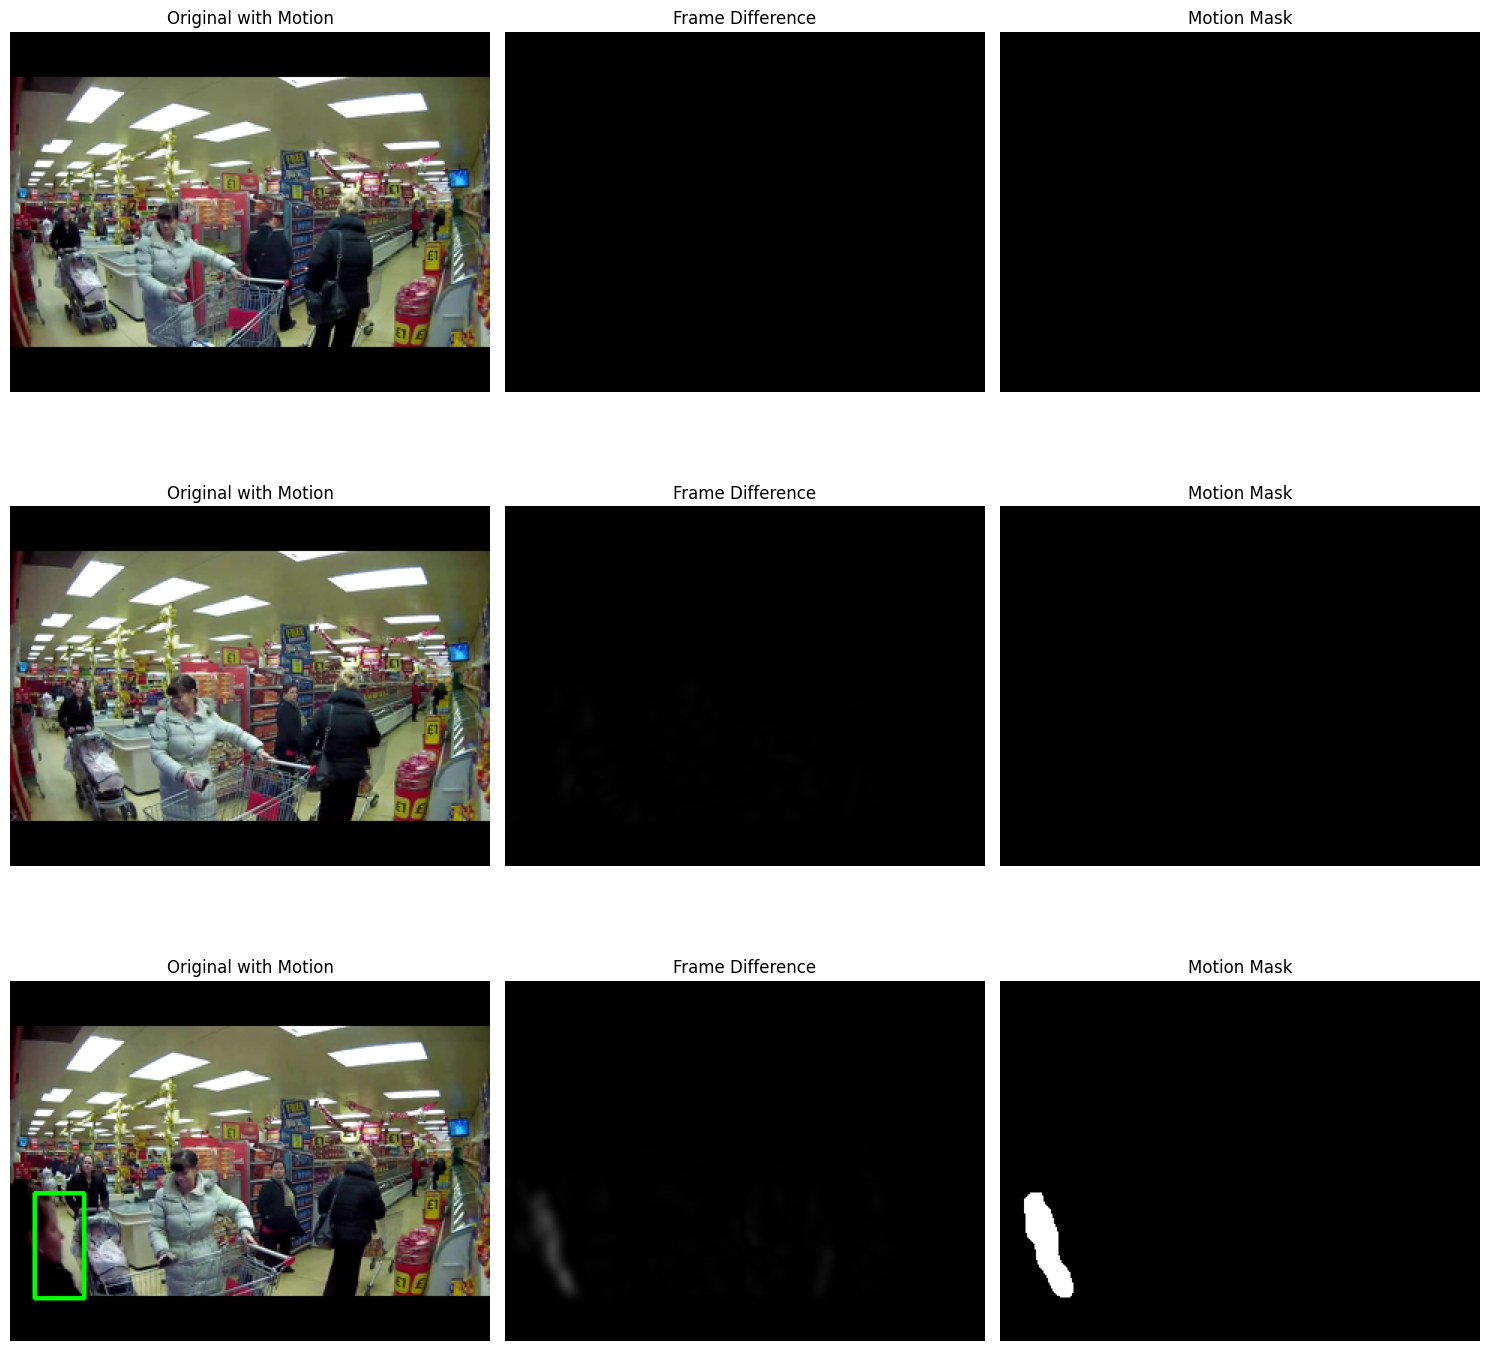

In [ ]:
# Function to display images
def display_frames(frames, titles=None, num_cols=3, figsize=(15, 5)):
    if not frames:
        print("No frames to display.")
        return

    num_frames = len(frames)
    num_rows = (num_frames + num_cols - 1) // num_cols # Calculate rows needed

    plt.figure(figsize=figsize)
    for i, frame in enumerate(frames):
        plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(frame)
        if titles and i < len(titles):
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Prepare titles for visualization (assuming 3 images per detected event: original, diff, dilated)
titles_per_event = ["Original with Motion", "Frame Difference", "Motion Mask"]
all_titles = []
for i in range(len(processed_frames) // len(titles_per_event)):
    all_titles.extend(titles_per_event)

# Display some processed frames
# We'll display the first few sets and maybe some from the middle/end if available
num_events_to_show = 3 # Show 3 sets of (original+diff+mask) from start
if len(processed_frames) // len(titles_per_event) > num_events_to_show:
    print(f"\nDisplaying first {num_events_to_show} detected motion events or sampled frames:")
    display_frames(processed_frames[:num_events_to_show * len(titles_per_event)],
                   titles=all_titles[:num_events_to_show * len(titles_per_event)],
                   figsize=(15, num_events_to_show * 5))
else:
    print(f"\nDisplaying all {len(processed_frames) // len(titles_per_event)} detected motion events or sampled frames:")
    display_frames(processed_frames,
                   titles=all_titles[:len(processed_frames)],
                   figsize=(15, (len(processed_frames) // len(titles_per_event)) * 5))

-----

### **5. Key Parameters & Further Experimentation**

  * **`min_area`**: This parameter in the `detect_motion_frame_differencing` function (e.g., `min_area=1000`) is crucial.
      * **Increase `min_area`**: Filters out smaller movements (e.g., camera shake, small noise). Only larger, more significant motion will be detected.
      * **Decrease `min_area`**: Detects more subtle movements, but might also pick up more noise.
  * **Threshold Value (`cv2.threshold`):**
      * The `25` in `cv2.threshold(frame_diff, 25, 255, cv2.THRESH_BINARY)` determines how large the pixel intensity difference must be to be considered motion.
      * **Increase threshold**: Makes the detection less sensitive to motion (requires larger changes).
      * **Decrease threshold**: Makes it more sensitive (detects smaller changes, potentially more noise).
  * **Gaussian Blur Kernel (`(21, 21)`):**
      * `cv2.GaussianBlur(gray_frame, (21, 21), 0)` applies blurring to smooth the image and reduce high-frequency noise before calculating differences.
      * A larger kernel size (e.g., `(31, 31)`) applies more blur, potentially making it less sensitive to very fine movements but more robust to sensor noise.
  * **Dilation Iterations (`iterations=2`):**
      * `cv2.dilate(thresh, None, iterations=2)` helps connect fragmented motion regions.
      * More iterations will expand the detected motion areas and close larger gaps, but might also merge distinct nearby movements.

**Try experimenting with these parameters and observe how the detection results change\!**
-----


### **6. Conclusion**

You have successfully implemented a basic motion detection system using frame differencing. While simple, this technique is foundational and demonstrates the power of analyzing temporal changes in video. It's often used as a preliminary step in more complex video analysis pipelines, such as initiating object tracking or triggering alerts.
